<a href="https://colab.research.google.com/github/manastasijas-pixel/Netology-project/blob/main/DLL_12_%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D1%81_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Обучить word2vec на фразах персонажей
Визуализировать embeddings по самым частотным словам (top 1000)
Найти самые близкие слова для: homer - marge + bart bart - lisa + school marge - homer + home

In [ ]:
!pip install numpy==1.26.4

In [ ]:
!pip install gensim

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from google.colab import files

import random

from gensim.models.word2vec import Word2Vec
from nltk.tokenize import word_tokenize

import nltk

from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
#чтобы загрузить файлы с данными в блокнот/ Вызвать команду столько раз, сколько файлов надо загрузить
dates = files.upload()

Saving simpsons_script_lines.csv to simpsons_script_lines.csv


In [ ]:
#Загрузим файл
df = pd.read_csv('simpsons_script_lines.csv')
df.head()

,id,episode_id,number,raw_text,timestamp_in_ms,speaking_line,character_id,location_id,raw_character_text,raw_location_text,spoken_words,normalized_text,word_count
0,9549,32,209,"Miss Hoover: No, actually, it was a little of ...",848000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,"No, actually, it was a little of both. Sometim...",no actually it was a little of both sometimes ...,31
1,9550,32,210,Lisa Simpson: (NEAR TEARS) Where's Mr. Bergstrom?,856000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,Where's Mr. Bergstrom?,wheres mr bergstrom,3
2,9551,32,211,Miss Hoover: I don't know. Although I'd sure l...,856000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,I don't know. Although I'd sure like to talk t...,i dont know although id sure like to talk to h...,22
3,9552,32,212,Lisa Simpson: That life is worth living.,864000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,That life is worth living.,that life is worth living,5
4,9553,32,213,Edna Krabappel-Flanders: The polls will be ope...,864000,True,40.0,3.0,Edna Krabappel-Flanders,Springfield Elementary School,The polls will be open from now until the end ...,the polls will be open from now until the end ...,33


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# список выражений сипсонов, каждый элемент списка - список из слов
sentences = [word_tokenize(text) for text in df['normalized_text'] if type(text) is str]

SyntaxError: expected 'else' after 'if' expression (ipython-input-12-1283682434.py, line 2)

In [ ]:
# посмотрим рандомный элемент
sentences[random.randint(0,len(sentences))]

['now', 'my', 'lips', 'are', 'getting', 'cold']

In [ ]:
%time model_simpsons = Word2Vec(sentences, workers=1, vector_size=300, min_count=3, window=5, epochs=15)

CPU times: user 59 s, sys: 302 ms, total: 59.3 s
Wall time: 1min 1s


In [ ]:
list(model_simpsons.wv.key_to_index.keys())[:10]

['the', 'you', 'i', 'a', 'to', 'and', 'of', 'it', 'that', 'my']

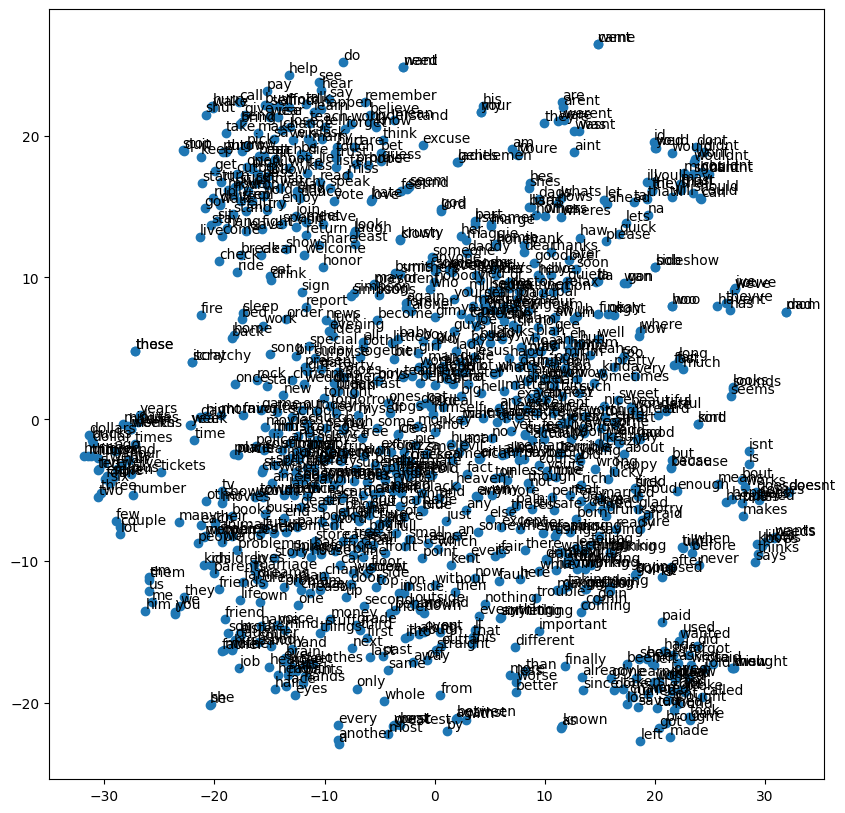

In [ ]:
n_top=1000 # сколько слов выведем на график
embedding_size = 300
top_tokens = list(model_simpsons.wv.key_to_index.keys())[:n_top]
top_embeddings = np.zeros([n_top, embedding_size])
for i in range(n_top):
  top_embeddings[i] = model_simpsons.wv[top_tokens[i]]

# переведем эмбединнги многомерные в 2хмерные, чтобы нарисовать график
tsne = TSNE(n_components=2, init='random', random_state=42)
z = tsne.fit_transform(top_embeddings)

plt.figure(figsize=(10, 10))
plt.scatter(z[:,0], z[:,1])

for i in range(len(z)):
  plt.annotate(top_tokens[i], (z[i,0], z[i,1] + 0.2))


In [ ]:
model_simpsons.wv.most_similar(positive=['homer', 'bart'], negative=['marge'], topn=5)

[('grampa', 0.4864378273487091),
 ('milhouse', 0.45755115151405334),
 ('son', 0.4454876184463501),
 ('lisa', 0.41320258378982544),
 ('dad', 0.40445584058761597)]

In [ ]:
model_simpsons.wv.most_similar(positive=['bart', 'school'], negative=['lisa'], topn=5)

[('class', 0.4602125585079193),
 ('church', 0.4597848653793335),
 ('store', 0.4593139886856079),
 ('plant', 0.42138510942459106),
 ('zoo', 0.4113507568836212)]

In [ ]:
model_simpsons.wv.most_similar(positive=['marge', 'home'], negative=['homer'], topn=5)

[('back', 0.4780076742172241),
 ('bed', 0.3791434168815613),
 ('bar', 0.3662358224391937),
 ('baby', 0.36216306686401367),
 ('visit', 0.36165904998779297)]